## Импорт библиотек

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re

## Предобработка

In [ ]:
df = pd.read_csv("drive/MyDrive/tech_support_topics.csv")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Document"] = df["Document"].astype(str).apply(clean_text)
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Topic_group"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["Document"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
def build_vocab(texts, max_vocab_size):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for idx, (word, _) in enumerate(counter.most_common(max_vocab_size - 2), start=2):
        vocab[word] = idx

    return vocab

In [ ]:
vocab = build_vocab(X_train, 10000)
vocab_size = len(vocab)
MAX_LEN = 100
num_classes = len(label_encoder.classes_)

In [ ]:
def encode_text(text, vocab, max_len):
    tokens = text.split()[:max_len]
    encoded = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    encoded += [vocab["<PAD>"]] * (max_len - len(encoded))
    return encoded

X_train_enc = [encode_text(text, vocab, MAX_LEN) for text in X_train]
X_test_enc  = [encode_text(text, vocab, MAX_LEN) for text in X_test]

In [ ]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train_enc, y_train)
test_dataset  = TextDataset(X_test_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

## LSTM

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_one_epoch(model, epoch, train_data_loader, test_data_loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, test_total_loss, test_correct = 0, 0, 0, 0
    progress_bar = tqdm(train_data_loader, desc=f"Epoch {epoch}", leave=False)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

        progress_bar.set_postfix_str(f"Loss: {total_loss / len(train_data_loader):.4f}, Accuracy: {correct / len(train_data_loader.dataset):.4f}")

    model.eval()
    with torch.no_grad():
        for images, labels in test_data_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_total_loss += loss.item()
            test_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = total_loss / len(train_data_loader)
    train_accuracy = correct / len(train_data_loader.dataset)
    test_loss = test_total_loss / len(test_data_loader)
    test_accuracy = test_correct / len(test_data_loader.dataset)
    return train_loss, train_accuracy, test_loss, test_accuracy

In [ ]:
epochs = 5
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(epochs):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model, epoch, train_loader, test_loader, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")


Epoch 1/5, Loss: 1.6675, Accuracy: 0.3723, Test Loss: 1.3144, Test Accuracy: 0.5373



Epoch 2/5, Loss: 1.0172, Accuracy: 0.6467, Test Loss: 0.7670, Test Accuracy: 0.7461



Epoch 3/5, Loss: 0.5849, Accuracy: 0.8128, Test Loss: 0.5307, Test Accuracy: 0.8306



Epoch 4/5, Loss: 0.4080, Accuracy: 0.8708, Test Loss: 0.4691, Test Accuracy: 0.8463



Epoch 5/5, Loss: 0.3123, Accuracy: 0.9005, Test Loss: 0.4646, Test Accuracy: 0.8520


In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print(f"Test Accuracy: {correct / total:.4f}")

Test Accuracy: 0.8520


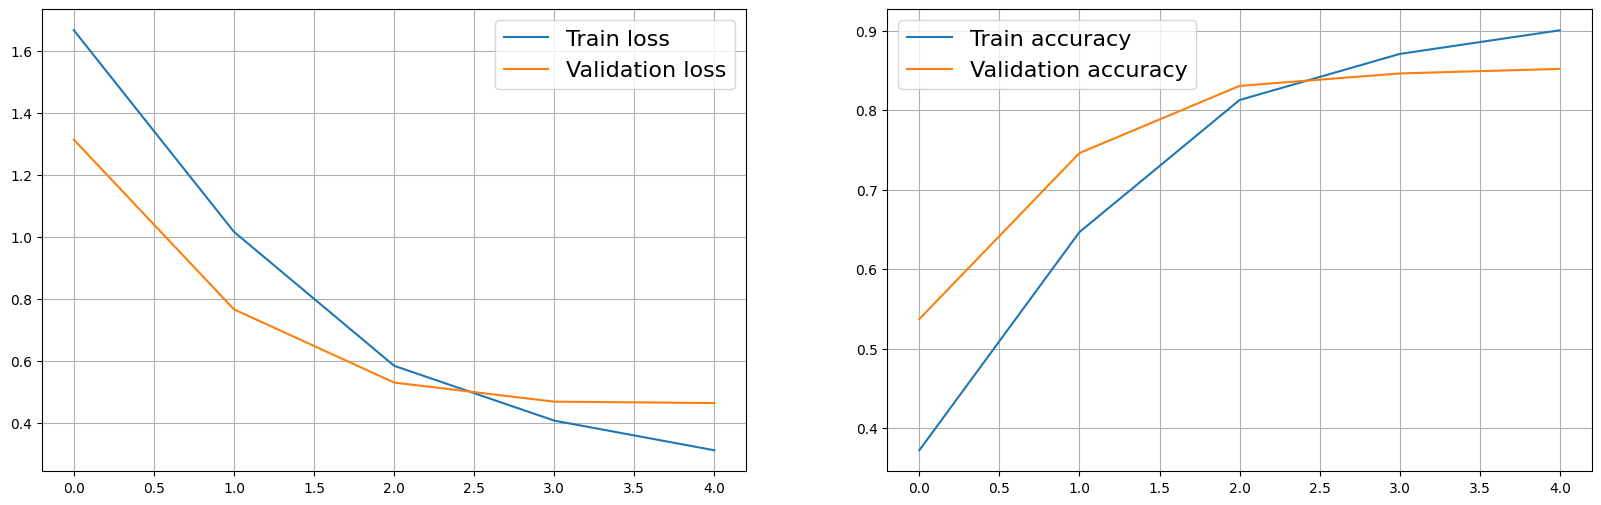

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

axs[0].plot(history['loss'], label='Train loss')
axs[0].plot(history['val_loss'], label='Validation loss')
axs[0].grid(True)
axs[0].legend(loc=1, prop={'size': 16})

axs[1].plot(history['accuracy'], label='Train accuracy')
axs[1].plot(history['val_accuracy'], label='Validation accuracy')
axs[1].grid(True)
axs[1].legend(loc=2, prop={'size': 16})

plt.show()

Модель быстро обучилась и уже с 3-4 эпохи точность начала выходить на плато, показав результат в 85%

## Bidirectional LSTM

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat((h_forward, h_backward), dim=1)
        return self.fc(h)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 5
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(epochs):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model, epoch, train_loader, test_loader, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")


Epoch 1/5, Loss: 0.7674, Accuracy: 0.7420, Test Loss: 0.5527, Test Accuracy: 0.8197



Epoch 2/5, Loss: 0.4248, Accuracy: 0.8571, Test Loss: 0.4443, Test Accuracy: 0.8539



Epoch 3/5, Loss: 0.3029, Accuracy: 0.8976, Test Loss: 0.4285, Test Accuracy: 0.8558



Epoch 4/5, Loss: 0.2137, Accuracy: 0.9291, Test Loss: 0.4475, Test Accuracy: 0.8589



Epoch 5/5, Loss: 0.1519, Accuracy: 0.9500, Test Loss: 0.4879, Test Accuracy: 0.8564


In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print(f"Test Accuracy: {correct / total:.4f}")

Test Accuracy: 0.8564


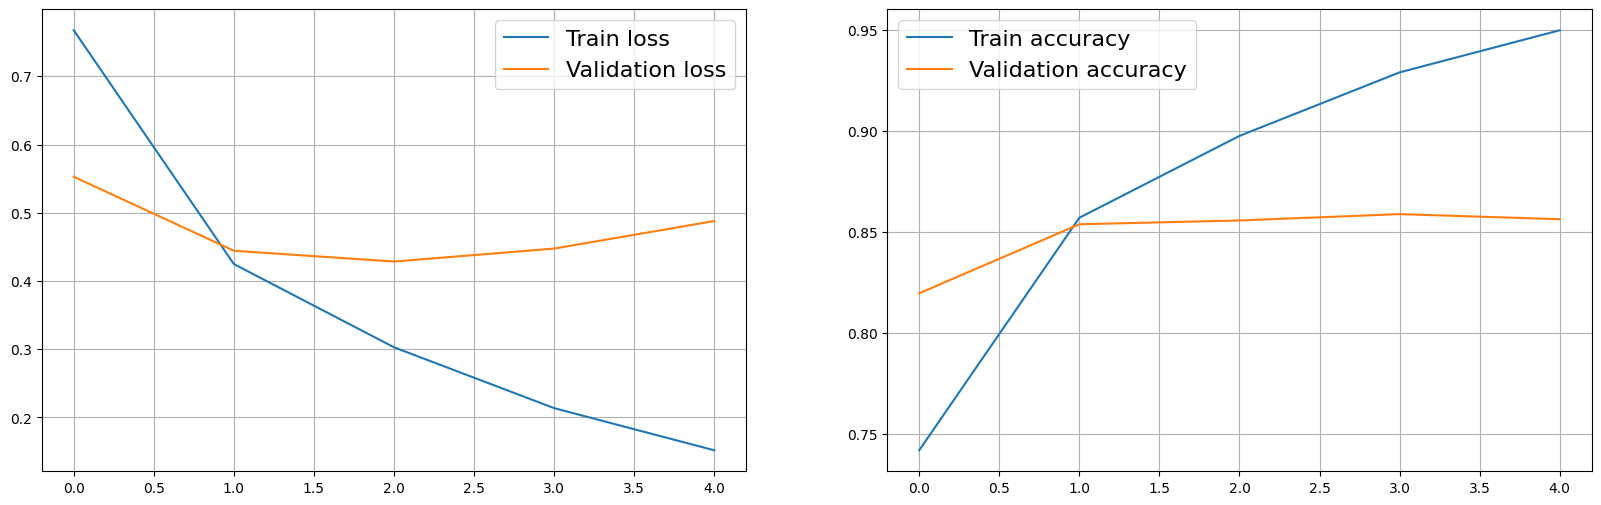

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

axs[0].plot(history['loss'], label='Train loss')
axs[0].plot(history['val_loss'], label='Validation loss')
axs[0].grid(True)
axs[0].legend(loc=1, prop={'size': 16})

axs[1].plot(history['accuracy'], label='Train accuracy')
axs[1].plot(history['val_accuracy'], label='Validation accuracy')
axs[1].grid(True)
axs[1].legend(loc=2, prop={'size': 16})

plt.show()

Видно, что модель быстро начала переобучаться, а точность вышла на плато буквально за пару эпох.

## Одномерная сверточная сеть

In [ ]:
class CNN1DClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.conv1d = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv1d(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.squeeze(2)

        return self.fc(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN1DClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
epochs = 5
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

for epoch in range(epochs):
    train_loss, accuracy, val_loss, val_accuracy = train_one_epoch(model, epoch, train_loader, test_loader, optimizer, criterion, device)
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(accuracy)
    history["val_accuracy"].append(val_accuracy)
    print(f"\nEpoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {accuracy:.4f}, Test Loss: {val_loss:.4f}, Test Accuracy: {val_accuracy:.4f}")


Epoch 1/5, Loss: 0.7084, Accuracy: 0.7601, Test Loss: 0.4985, Test Accuracy: 0.8273



Epoch 2/5, Loss: 0.3735, Accuracy: 0.8709, Test Loss: 0.4665, Test Accuracy: 0.8363



Epoch 3/5, Loss: 0.2537, Accuracy: 0.9127, Test Loss: 0.4799, Test Accuracy: 0.8364



Epoch 4/5, Loss: 0.1618, Accuracy: 0.9483, Test Loss: 0.5149, Test Accuracy: 0.8365



Epoch 5/5, Loss: 0.0977, Accuracy: 0.9724, Test Loss: 0.5787, Test Accuracy: 0.8354


In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print(f"Test Accuracy: {correct / total:.4f}")

Test Accuracy: 0.8354


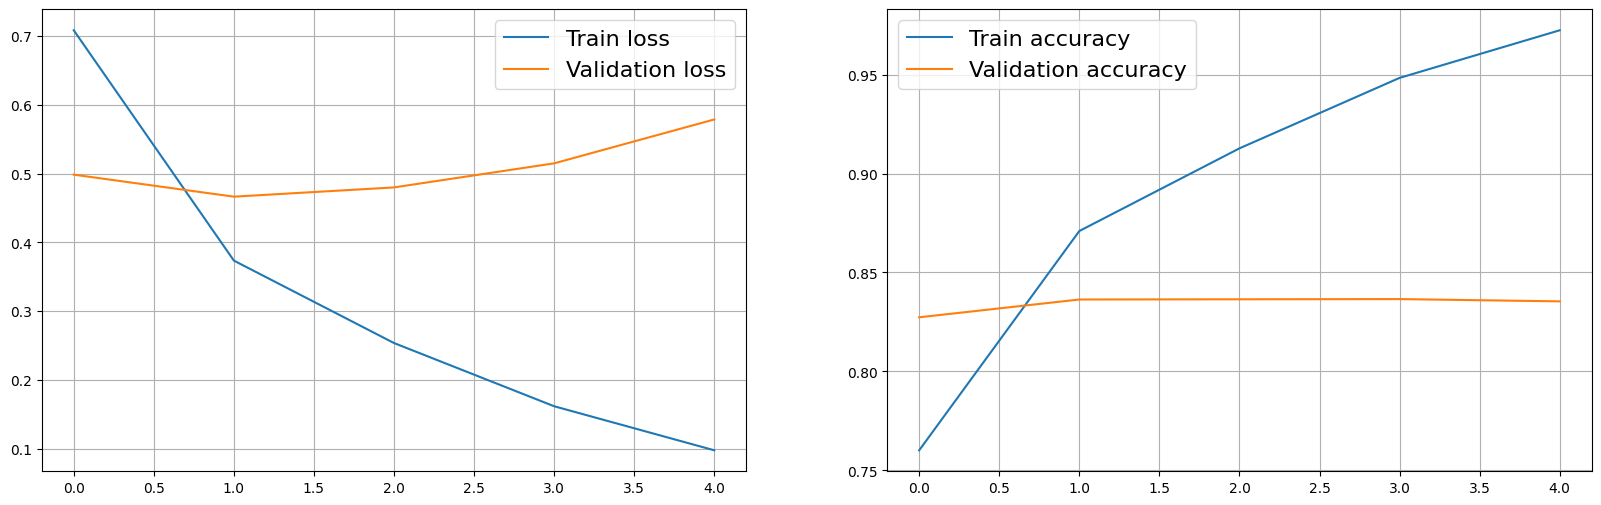

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6))

axs[0].plot(history['loss'], label='Train loss')
axs[0].plot(history['val_loss'], label='Validation loss')
axs[0].grid(True)
axs[0].legend(loc=1, prop={'size': 16})

axs[1].plot(history['accuracy'], label='Train accuracy')
axs[1].plot(history['val_accuracy'], label='Validation accuracy')
axs[1].grid(True)
axs[1].legend(loc=2, prop={'size': 16})

plt.show()

Уже с первой эпохи модель показала точность в 83%, а с 3й эпохи потери начали расти

## Вывод

Рекуррентные модели показали примерно одинаковый результат в 85%, а одномерная сверточная 83%. Притом их обучение занимало приблизительно одинаковое время.